# DDSM PIPELINE 
THE PIPELINE CONSISTS OF READING THE DATA THEN PREPROCESSING THEN IMPLEMENTING CNN THEN ENHANCED CNN AND THEN THREE TRANSFER LEARNING MODELS AND THE BEST TRANSFER LEARNING MODEL WILL BE OPTIMIZED WITH THRESHOLD OPTIMIZATION AND FINETUING WITH BALANCING THE DATA WITH MINORITY OVERSAMPLING 

Importing all the required libraries 

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os
import tensorflow as tf
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, classification_report, confusion_matrix, f1_score, auc

from tensorflow.keras.applications import ResNet50, VGG16
from tensorflow.keras import models, layers
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

## Reading The Data



Reading the data from kaggle and caching it

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("skooch/ddsm-mammography")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'ddsm-mammography' dataset.
Path to dataset files: /kaggle/input/ddsm-mammography


In [ ]:
import os
import glob
import numpy as np
train_dirs = [os.path.join(path, d) for d in os.listdir(path) if d.startswith("training")]

train_tfrecords = []
for d in train_dirs:
    train_tfrecords.extend(glob.glob(os.path.join(d, "*.tfrecords")))


print("Training TFRecords:", len(train_tfrecords))


Training TFRecords: 5


## Preprocessing

We preprocess the data first by extracting the image and the label from the tfrecord

Then we preprocess it by reshaping it and resizing it (100,100)
and making it 3 dimensions

In [ ]:
images=[]
labels=[]
feature_dictionary = {
    'label': tf.io.FixedLenFeature([], tf.int64),
    'label_normal': tf.io.FixedLenFeature([], tf.int64),
    'image': tf.io.FixedLenFeature([], tf.string)
    }
def _parse_function(example, feature_dictionary=feature_dictionary):
    parsed_example = tf.io.parse_example(example, feature_dictionary)
    return parsed_example

def read_data(filename):
    full_dataset = tf.data.TFRecordDataset(filename,num_parallel_reads=tf.data.experimental.AUTOTUNE)
    full_dataset = full_dataset.shuffle(buffer_size=31000)
    full_dataset = full_dataset.cache()
    print("Size of Training Dataset: ", len(list(full_dataset)))

    feature_dictionary = {
    'label': tf.io.FixedLenFeature([], tf.int64),
    'label_normal': tf.io.FixedLenFeature([], tf.int64),
    'image': tf.io.FixedLenFeature([], tf.string)
    }

    full_dataset = full_dataset.map(_parse_function, num_parallel_calls=tf.data.experimental.AUTOTUNE)
    print(full_dataset)
    for image_features in full_dataset:
        image = image_features['image'].numpy()
        image = tf.io.decode_raw(image_features['image'], tf.uint8)
        image = tf.reshape(image, [299, 299])
        image=image.numpy()
        image=cv2.resize(image,(100,100))
        image=cv2.merge([image,image,image])
        images.append(image)
        labels.append(image_features['label_normal'].numpy())

for file in train_tfrecords:
    read_data(file)

print(len(images))
print(len(labels))

Size of Training Dataset:  11177
<_ParallelMapDataset element_spec={'image': TensorSpec(shape=(), dtype=tf.string, name=None), 'label': TensorSpec(shape=(), dtype=tf.int64, name=None), 'label_normal': TensorSpec(shape=(), dtype=tf.int64, name=None)}>
Size of Training Dataset:  11177
<_ParallelMapDataset element_spec={'image': TensorSpec(shape=(), dtype=tf.string, name=None), 'label': TensorSpec(shape=(), dtype=tf.int64, name=None), 'label_normal': TensorSpec(shape=(), dtype=tf.int64, name=None)}>
Size of Training Dataset:  11177
<_ParallelMapDataset element_spec={'image': TensorSpec(shape=(), dtype=tf.string, name=None), 'label': TensorSpec(shape=(), dtype=tf.int64, name=None), 'label_normal': TensorSpec(shape=(), dtype=tf.int64, name=None)}>
Size of Training Dataset:  11177
<_ParallelMapDataset element_spec={'image': TensorSpec(shape=(), dtype=tf.string, name=None), 'label': TensorSpec(shape=(), dtype=tf.int64, name=None), 'label_normal': TensorSpec(shape=(), dtype=tf.int64, name=None

In [ ]:
from sklearn.model_selection import train_test_split

X=np.array(images)
y=np.array(labels)


In [ ]:
X_train,X_val,y_train,y_val = train_test_split(X,y,test_size=0.25)
X_train,X_test,y_train,y_test = train_test_split(X_train,y_train,test_size=0.2)

In [ ]:
print(type(X_train), type(y_train))
print(len(X_train), len(y_train))
print(X_train[0].shape)


<class 'numpy.ndarray'> <class 'numpy.ndarray'>
33530 33530
(100, 100, 3)


## Visualizing Samples


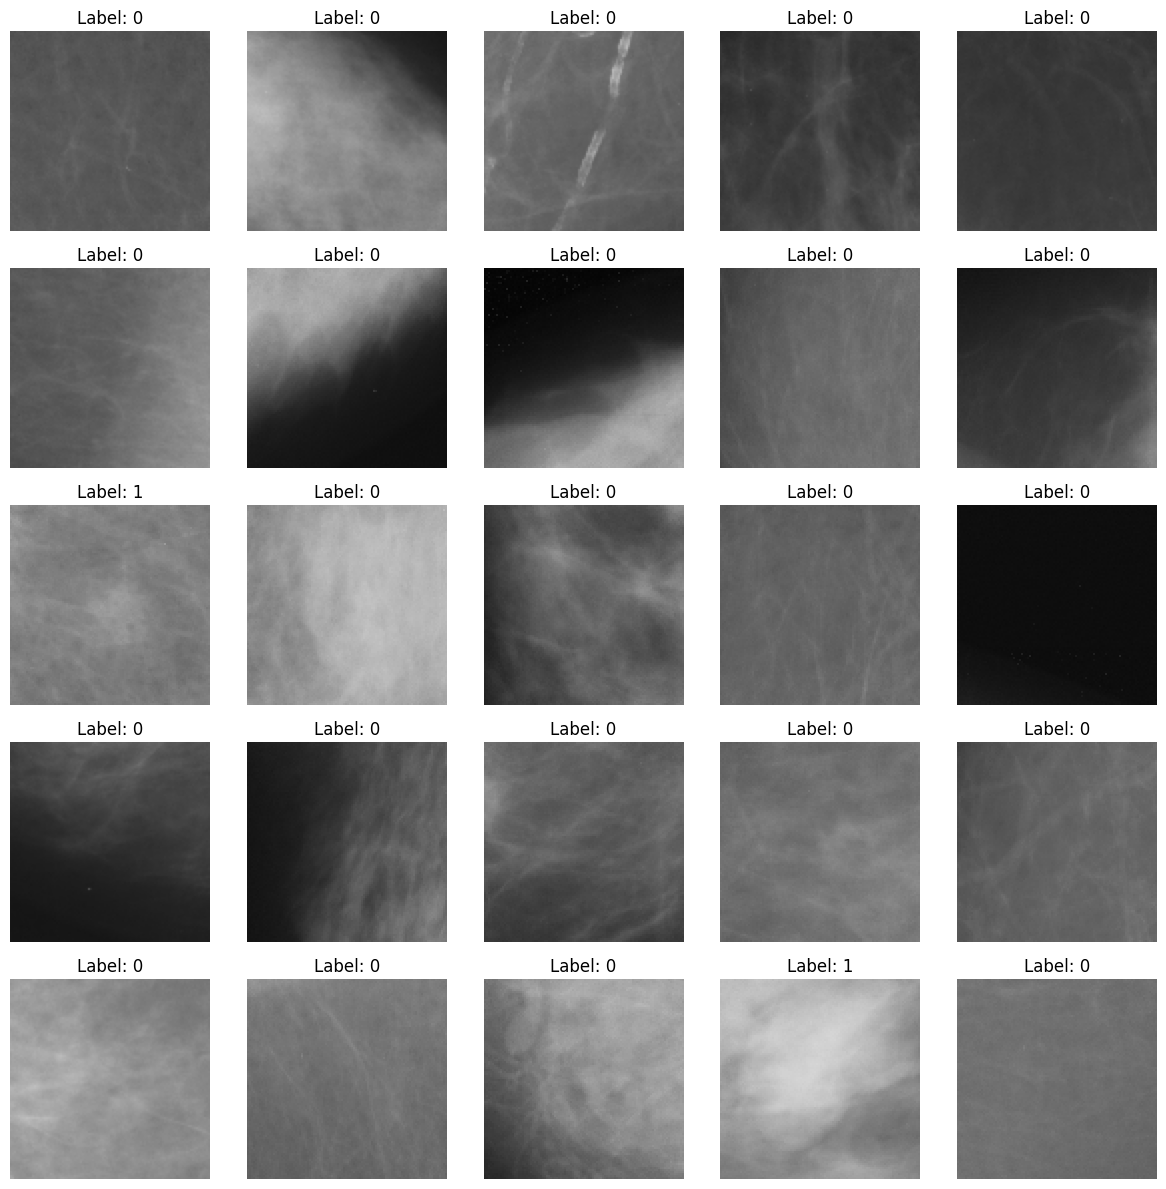

In [ ]:
import matplotlib.pyplot as plt


def show_image_grid(images, labels, n=25):
    plt.figure(figsize=(12, 12))
    for i in range(min(n, len(images))):
        plt.subplot(5, 5, i + 1)
        plt.imshow(images[i], cmap='gray')
        plt.title(f"Label: {labels[i]}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

show_image_grid(images, labels, n=25)


## CNN MODEL

We will start with simple CNN model


In [ ]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models,regularizers

def create_cnn(input_shape, num_classes):
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.Flatten(),

        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model


In [ ]:
input_shape = (100, 100, 3)

with tf.device('/GPU:0'):
    model = create_cnn(input_shape=input_shape, num_classes=1)
    model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 98, 98, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 56448)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,225,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,318,849 (27.92 MB)

 Trainable params: 7,318,849 (27.92 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping]
)

Epoch 1/50
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 28s 19ms/step - accuracy: 0.8482 - loss: 4.1695 - val_accuracy: 0.8753 - val_loss: 0.4435
Epoch 2/50
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - accuracy: 0.8667 - loss: 0.4499 - val_accuracy: 0.8753 - val_loss: 0.3764
Epoch 3/50
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - accuracy: 0.8680 - loss: 0.3851 - val_accuracy: 0.8753 - val_loss: 0.3681
Epoch 4/50
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - accuracy: 0.8696 - loss: 0.3726 - val_accuracy: 0.8753 - val_loss: 0.3610
Epoch 5/50
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - accuracy: 0.8682 - loss: 0.3986 - val_accuracy: 0.8753 - val_loss: 0.3781
Epoch 6/50
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - accuracy: 0.8719 - loss: 0.3834 - val_accuracy: 0.8753 - val_loss: 0.3830
Epoch 7/50
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - accuracy: 0.8675 - loss: 0.3939 - val_accuracy: 0.8753 - val_loss: 0.3820
Epoch 8/50
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - accuracy: 0.8657 -

Let's Evaluate the model By


1.   Classification Report
2. Confusion Matrix
3. ROC Curve




In [ ]:
pred_probs = model.predict(X_test)
pred_classes = (pred_probs > 0.5).astype(int).flatten()


262/262 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, pred_classes))
print(confusion_matrix(y_test, pred_classes))


              precision    recall  f1-score   support

           0       0.87      1.00      0.93      7262
           1       0.00      0.00      0.00      1121

    accuracy                           0.87      8383
   macro avg       0.43      0.50      0.46      8383
weighted avg       0.75      0.87      0.80      8383

[[7262    0]
 [1121    0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
np.unique(pred_classes,return_counts=True)

(array([0]), array([8383]))

In [ ]:
np.unique(y_test,return_counts=True)

(array([0, 1]), array([7262, 1121]))

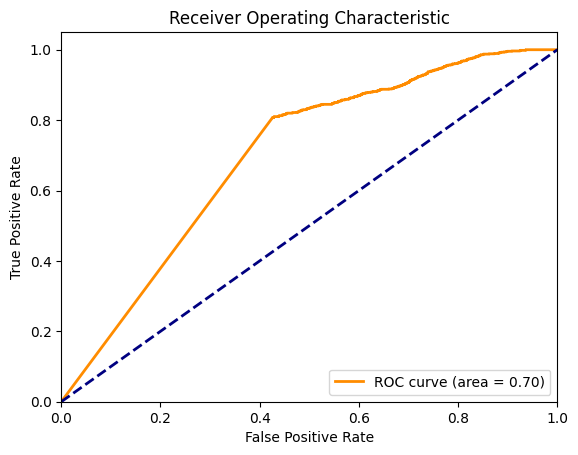

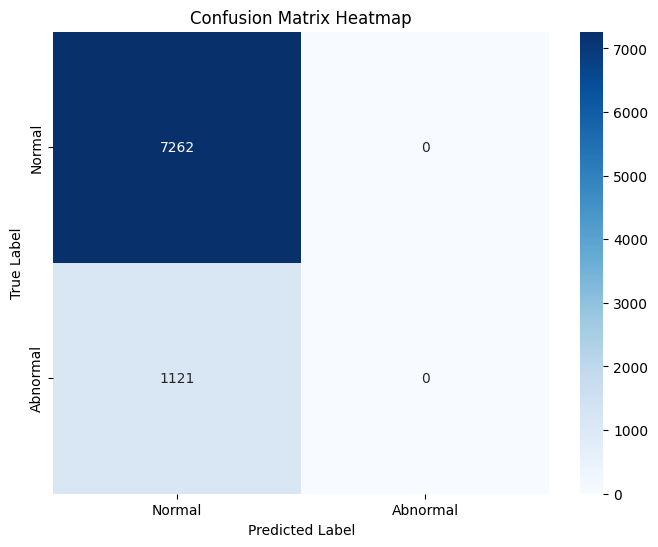

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

fpr, tpr, thresholds = roc_curve(y_test, pred_probs)
roc_auc = auc(fpr, tpr)


plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

cm = confusion_matrix(y_test, pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Abnormal'], yticklabels=['Normal', 'Abnormal'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap')
plt.show()

biased results but inspires us to do more complex network can get better results

## Enhanced CNN model

Adding more Conv and MaxPooling Layers

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models,regularizers

def create_enhanced_cnn(input_shape, num_classes=1):
     model = models.Sequential([
        layers.Conv2D(128, (3,3), activation='relu', padding='same', input_shape=input_shape),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.2),

        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.2),

        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.2),


        layers.Conv2D(512, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.3),

        layers.Conv2D(512, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.3),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])

     model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='AUC')]
    )

     return model

In [ ]:
input_shape = (100, 100, 3)

with tf.device('/GPU:0'):
    model = create_enhanced_cnn(input_shape=input_shape)
    model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 100, 100, 128)  │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 50, 50, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 50, 50, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 25, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 25, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 25, 25, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 1, 1, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 1, 1, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,707,969 (17.96 MB)

 Trainable params: 4,707,969 (17.96 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping]
)

Epoch 1/50
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 81s 65ms/step - AUC: 0.4141 - accuracy: 0.8534 - loss: 0.6350 - val_AUC: 0.8195 - val_accuracy: 0.8753 - val_loss: 0.3336
Epoch 2/50
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 52s 50ms/step - AUC: 0.7580 - accuracy: 0.8678 - loss: 0.3375 - val_AUC: 0.8412 - val_accuracy: 0.8753 - val_loss: 0.3224
Epoch 3/50
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 52s 50ms/step - AUC: 0.8167 - accuracy: 0.8691 - loss: 0.3068 - val_AUC: 0.8764 - val_accuracy: 0.8773 - val_loss: 0.3319
Epoch 4/50
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 52s 50ms/step - AUC: 0.8335 - accuracy: 0.8715 - loss: 0.2961 - val_AUC: 0.8588 - val_accuracy: 0.8775 - val_loss: 0.4077
Epoch 5/50
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 52s 50ms/step - AUC: 0.8518 - accuracy: 0.8737 - loss: 0.2890 - val_AUC: 0.9031 - val_accuracy: 0.8838 - val_loss: 0.3351
Epoch 6/50
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 52s 50ms/step - AUC: 0.8770 - accuracy: 0.8831 - loss: 0.2690 - val_AUC: 0.8389 - val_accuracy: 0.8842 - val_loss: 0.5091
Epoch 7/50
1048/

Let's Evaluate the model By


1.   Classification Report
2. Confusion Matrix
3. ROC Curve




In [ ]:
pred_probs = model.predict(X_test)
pred_classes = (pred_probs > 0.5).astype(int).flatten()


262/262 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, pred_classes))
print(confusion_matrix(y_test, pred_classes))


              precision    recall  f1-score   support

           0       0.89      1.00      0.94      7262
           1       0.93      0.21      0.35      1121

    accuracy                           0.89      8383
   macro avg       0.91      0.61      0.65      8383
weighted avg       0.90      0.89      0.86      8383

[[7244   18]
 [ 880  241]]


In [ ]:
np.unique(pred_classes,return_counts=True)

(array([0, 1]), array([8124,  259]))

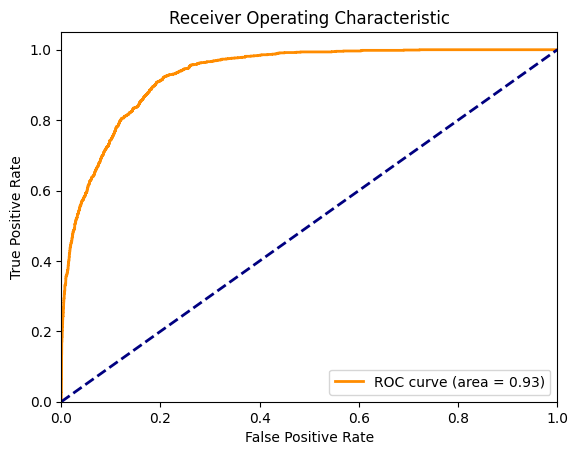

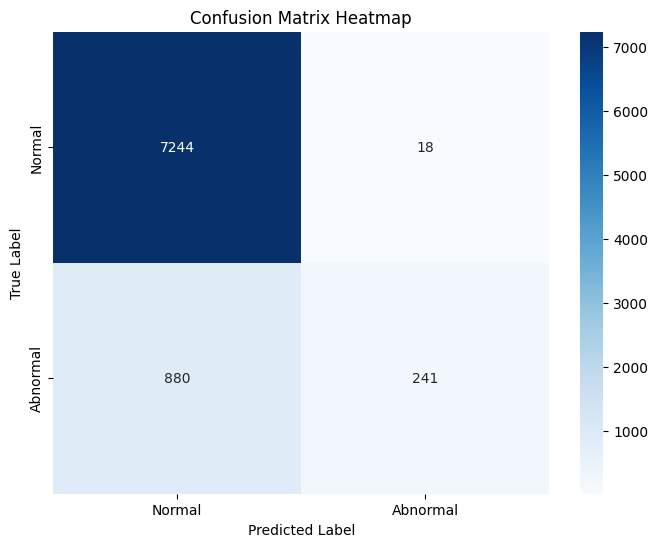

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

fpr, tpr, thresholds = roc_curve(y_test, pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

cm = confusion_matrix(y_test, pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Abnormal'], yticklabels=['Normal', 'Abnormal'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap')
plt.show()

Actually better But still not enough

that mean with more complexity we can solve the bias problem for better results
so let's Try Transfer Learning

In [ ]:
model.save('/content/drive/MyDrive/breast_cancer_lu/CNN_enhanced_model_breast_cancer.h5')

## RESNET50

We Will start with ResNet50

Removing the Top classifier of it and add our classifier
Freeze all layers as they will not be trainable

In [ ]:

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(60, 60, 3)
)

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
output = Dense(1, activation='sigmoid')(x)

model_resnet = Model(inputs=base_model.input, outputs=output)

model_resnet.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

model_resnet.summary()


Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 100, 100,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 106, 106,  │          0 │ input_layer_8[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 50, 50,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 50, 50,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 50, 50,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 52, 52,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 25, 25,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 25, 25,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 25, 25,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 25, 25,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 25, 25,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 25, 25,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 25, 25,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 25, 25,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 25, 25,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 25, 25,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 25, 25,    │      1,024 │ conv2_block1_3_c

 Total params: 24,112,513 (91.98 MB)

 Trainable params: 524,801 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
os.makedirs("checkpoints", exist_ok=True)

early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    mode='max',
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    filepath="checkpoints/best_resnet50.h5",
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)


In [ ]:
history_resnet = model_resnet.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    callbacks=[early_stopping, checkpoint],
    verbose=1
)

Let's Evaluate the model By


1.   Classification Report
2. Confusion Matrix
3. ROC Curve




In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

pred_probs = model_resnet.predict(X_test)
pred_classes = (pred_probs > 0.5).astype(int).flatten()

print(classification_report(y_test, pred_classes))
print(confusion_matrix(y_test, pred_classes))


262/262 ━━━━━━━━━━━━━━━━━━━━ 17s 49ms/step
              precision    recall  f1-score   support

           0       0.96      0.97      0.96      7287
           1       0.79      0.70      0.74      1096

    accuracy                           0.94      8383
   macro avg       0.87      0.84      0.85      8383
weighted avg       0.93      0.94      0.94      8383

[[7083  204]
 [ 327  769]]


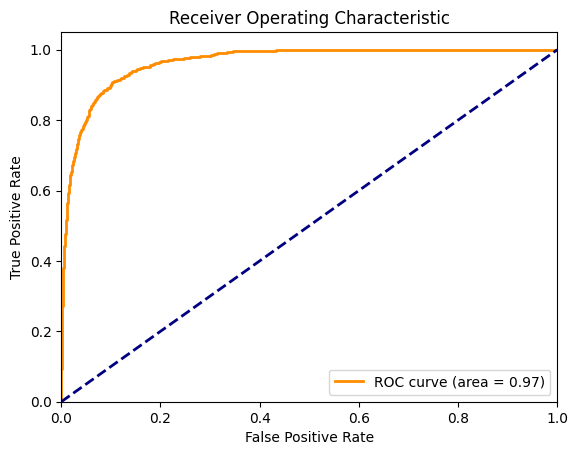

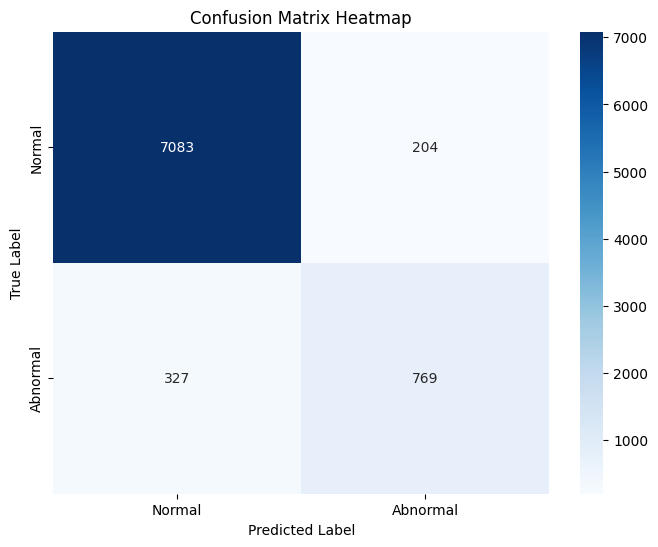

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

fpr, tpr, thresholds = roc_curve(y_test, pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

cm = confusion_matrix(y_test, pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Abnormal'], yticklabels=['Normal', 'Abnormal'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap')
plt.show()

In [ ]:
model.save("/content/drive/MyDrive/breast_cancer_lu/resnet_model_breast_cancer.h5")

The best yet:


1.   Very good Auc and accuracy
2. the bias problem Almost Solved


## DenseNet

Let's Look At DenseNet

Removing the Top classifier of it and add our classifier
Freeze all layers as they will not be trainable

In [ ]:
from tensorflow.keras.applications import DenseNet121

base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(100, 100, 3)
)

base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')  # Binary classification
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='AUC')]
)

model.summary()


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 3, 3, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,956,801 (30.35 MB)

 Trainable params: 919,297 (3.51 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [ ]:
early_stopping = EarlyStopping(monitor='val_accuracy', patience=7, restore_best_weights=True)

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping]
)

Epoch 1/50
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 109s 74ms/step - AUC: 0.7760 - accuracy: 0.8527 - loss: 0.4079 - val_AUC: 0.8899 - val_accuracy: 0.8933 - val_loss: 0.2506
Epoch 2/50
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 83s 34ms/step - AUC: 0.8840 - accuracy: 0.8860 - loss: 0.2645 - val_AUC: 0.9065 - val_accuracy: 0.8893 - val_loss: 0.2890
Epoch 3/50
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 35s 34ms/step - AUC: 0.8985 - accuracy: 0.8978 - loss: 0.2448 - val_AUC: 0.9158 - val_accuracy: 0.8967 - val_loss: 0.2350
Epoch 4/50
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 35s 34ms/step - AUC: 0.9125 - accuracy: 0.8986 - loss: 0.2362 - val_AUC: 0.9195 - val_accuracy: 0.8918 - val_loss: 0.2610
Epoch 5/50
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 36s 34ms/step - AUC: 0.9157 - accuracy: 0.9023 - loss: 0.2331 - val_AUC: 0.9233 - val_accuracy: 0.9065 - val_loss: 0.2140
Epoch 6/50
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 36s 34ms/step - AUC: 0.9244 - accuracy: 0.9059 - loss: 0.2186 - val_AUC: 0.9197 - val_accuracy: 0.9071 - val_loss: 0.2188
Epoch 7/50
1048

Let's Evaluate the model By


1.   Classification Report
2. Confusion Matrix
3. ROC Curve




In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

pred_probs = model.predict(X_test)
pred_classes = (pred_probs > 0.5).astype(int).flatten()

print(classification_report(y_test, pred_classes))
print(confusion_matrix(y_test, pred_classes))


262/262 ━━━━━━━━━━━━━━━━━━━━ 34s 81ms/step
              precision    recall  f1-score   support

           0       0.93      0.98      0.95      7262
           1       0.76      0.50      0.60      1121

    accuracy                           0.91      8383
   macro avg       0.84      0.74      0.78      8383
weighted avg       0.90      0.91      0.90      8383

[[7084  178]
 [ 562  559]]


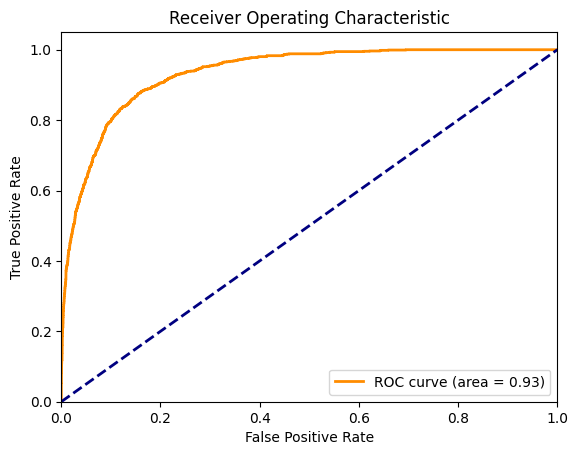

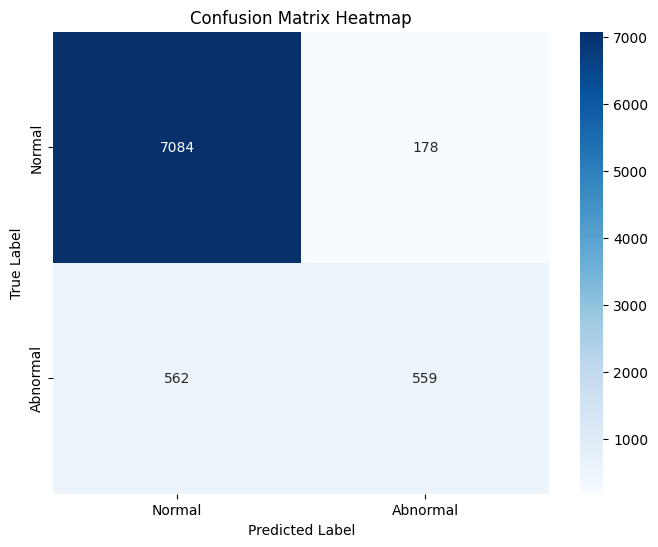

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

fpr, tpr, thresholds = roc_curve(y_test, pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

cm = confusion_matrix(y_test, pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Abnormal'], yticklabels=['Normal', 'Abnormal'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap')
plt.show()

In [ ]:
model.save('/content/drive/MyDrive/breast_cancer_lu/densenet_model_breast_cancer_balanced.h5')

Still good but not better Than ResNet and more biased

## VGG16

Let's Look At VGG16

Removing the Top classifier of it and add our classifier
Freeze all layers as they will not be trainable

In [ ]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(100, 100, 3)
)

base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='AUC')]
)

In [ ]:
early_stopping = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_vgg16_model.keras', save_best_only=True, monitor='val_accuracy')



In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    callbacks=[early_stopping, checkpoint]
)

Epoch 1/30
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 85s 74ms/step - AUC: 0.7286 - accuracy: 0.8524 - loss: 0.4394 - val_AUC: 0.8606 - val_accuracy: 0.8941 - val_loss: 0.2675
Epoch 2/30
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 69s 66ms/step - AUC: 0.8595 - accuracy: 0.8898 - loss: 0.2765 - val_AUC: 0.8688 - val_accuracy: 0.9000 - val_loss: 0.2582
Epoch 3/30
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 68s 65ms/step - AUC: 0.8811 - accuracy: 0.8938 - loss: 0.2572 - val_AUC: 0.8817 - val_accuracy: 0.8998 - val_loss: 0.2494
Epoch 4/30
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 69s 65ms/step - AUC: 0.8937 - accuracy: 0.8953 - loss: 0.2510 - val_AUC: 0.8876 - val_accuracy: 0.9030 - val_loss: 0.2444
Epoch 5/30
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 68s 65ms/step - AUC: 0.8989 - accuracy: 0.9037 - loss: 0.2399 - val_AUC: 0.8938 - val_accuracy: 0.8977 - val_loss: 0.2549
Epoch 6/30
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 69s 66ms/step - AUC: 0.9050 - accuracy: 0.9011 - loss: 0.2387 - val_AUC: 0.8951 - val_accuracy: 0.9034 - val_loss: 0.2378
Epoch 7/30
1048/

Let's Evaluate the model By


1.   Classification Report
2. Confusion Matrix
3. ROC Curve




In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

pred_probs = model.predict(X_test)
pred_classes = (pred_probs > 0.5).astype(int).flatten()

print(classification_report(y_test, pred_classes))
print(confusion_matrix(y_test, pred_classes))


262/262 ━━━━━━━━━━━━━━━━━━━━ 15s 54ms/step
              precision    recall  f1-score   support

           0       0.92      0.97      0.95      7262
           1       0.71      0.48      0.57      1121

    accuracy                           0.90      8383
   macro avg       0.81      0.72      0.76      8383
weighted avg       0.89      0.90      0.90      8383

[[7039  223]
 [ 587  534]]


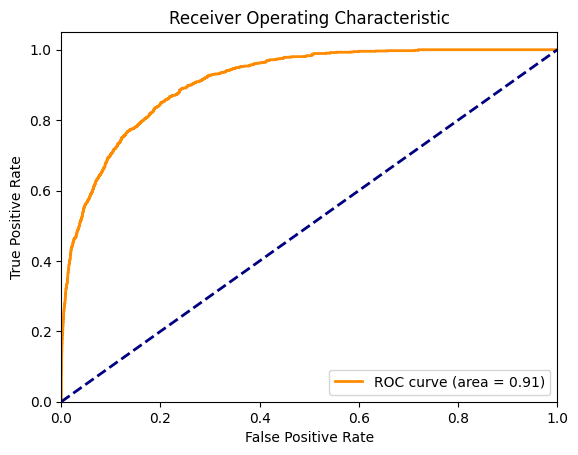

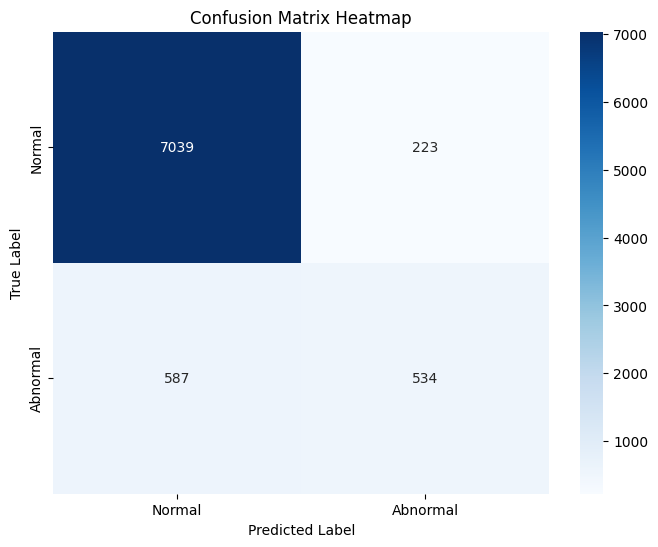

In [ ]:


fpr, tpr, thresholds = roc_curve(y_test, pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

cm = confusion_matrix(y_test, pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Abnormal'], yticklabels=['Normal', 'Abnormal'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap')
plt.show()

In [ ]:
model.save('/content/drive/MyDrive/breast_cancer_lu/vgg_model_breast_cancer_lu.h5')

Close to the Densenet Results so the best model was ResNet

## Resnet Fine-tuning

ResNet model was good but we are looking for Higher recall and F1 score specially for label 1 as for our case the higher recall the better as it means it detects more cancer cases

Load Resnet model

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from tensorflow.keras.models import load_model

model_resnet = load_model("/content/drive/MyDrive/breast_cancer_lu/resnet_model_breast_cancer.h5")

# Predict probabilities normally (no training)
pred_probs = model_resnet.predict(X_test).flatten()

262/262 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step


Calculate the best threshold for the F1 score

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, pred_probs)
f1_scores = []
for th in thresholds:
    preds = (pred_probs > th).astype(int)
    f1_scores.append(f1_score(y_test, preds))

best_f1_threshold = thresholds[np.argmax(f1_scores)]

print("Best Threshold (F1-score):", best_f1_threshold)


Best Threshold (F1-score): 0.13916637


plot of thresholds

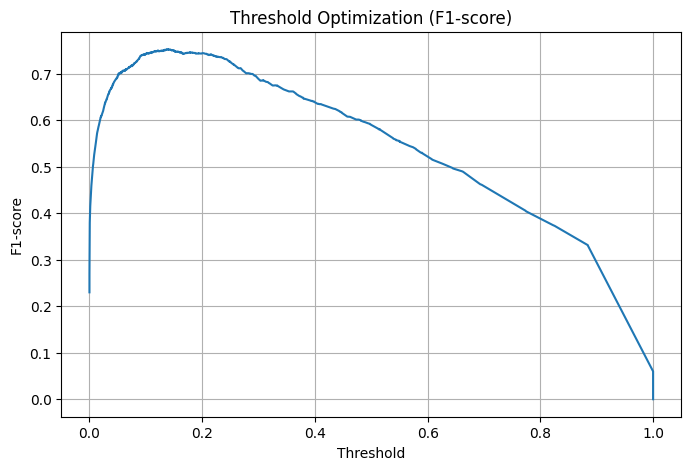

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(thresholds, f1_scores)
plt.xlabel("Threshold")
plt.ylabel("F1-score")
plt.title("Threshold Optimization (F1-score)")
plt.grid(True)
plt.show()


getting the best threshold

In [ ]:
final_threshold = best_f1_threshold

pred_classes_opt = (pred_probs > final_threshold).astype(int)

print("\nClassification Report with Optimized Threshold:")
print(classification_report(y_test, pred_classes_opt))

cm = confusion_matrix(y_test, pred_classes_opt)
print("Confusion Matrix:\n", cm)



Classification Report with Optimized Threshold:
              precision    recall  f1-score   support

           0       0.96      0.97      0.96      7317
           1       0.77      0.74      0.75      1066

    accuracy                           0.94      8383
   macro avg       0.87      0.85      0.86      8383
weighted avg       0.94      0.94      0.94      8383

Confusion Matrix:
 [[7082  235]
 [ 281  785]]


A lot better F1 score and recall for label 1 with the same accuracy

and also the weighted precision increased to 0.94

Let's see the ROC curve

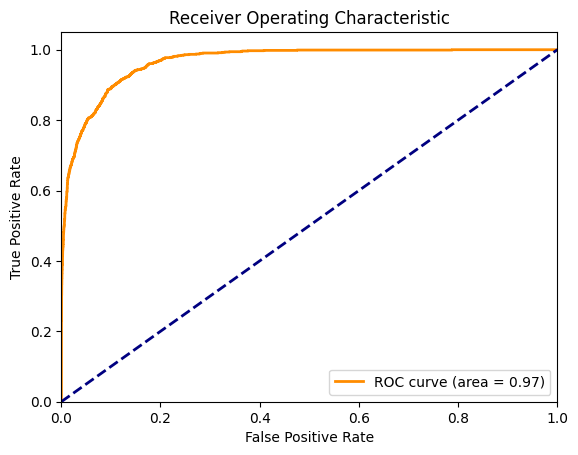

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()


stays the same which is good

Let's see the confusion matrix

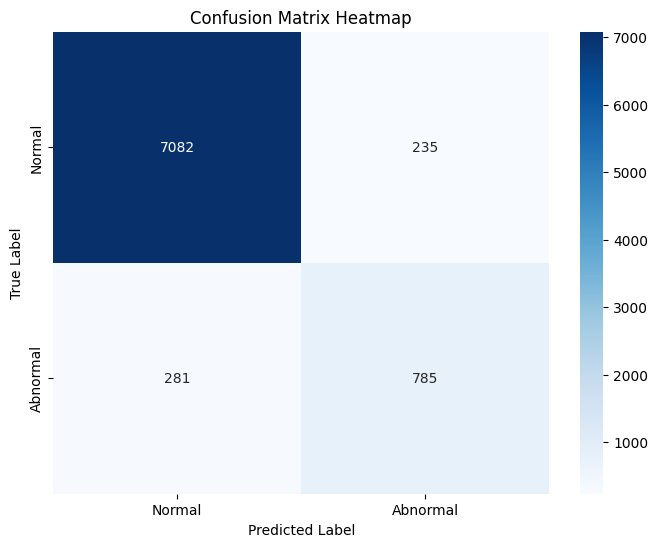

In [ ]:

cm = confusion_matrix(y_test, pred_classes_opt)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Abnormal'], yticklabels=['Normal', 'Abnormal'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap')
plt.show()

Model is now catching more positives

TP increased 769 to 785

FN decreased 327 to 281

Now we unfreeze some ResNet layers and train a bit.

In [ ]:
# Unfreeze last 30 layers only (safe tuning)
for layer in model_resnet.layers[-30:]:
    layer.trainable = True

model_resnet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='AUC')]
)

model_resnet.summary()


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_30 (Conv2D)              │ (None, 100, 100, 128)  │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_30 (MaxPooling2D) │ (None, 50, 50, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 50, 50, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_31 (MaxPooling2D) │ (None, 25, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 25, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 25, 25, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_32 (MaxPooling2D) │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_33 (MaxPooling2D) │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_34 (MaxPooling2D) │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_35 (Dropout)            │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_35 (MaxPooling2D) │ (None, 1, 1, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_36 (Dropout)            │ (None, 1, 1, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_37 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,707,969 (17.96 MB)

 Trainable params: 4,707,969 (17.96 MB)

 Non-trainable params: 0 (0.00 B)

train the model

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
checkpoint = ModelCheckpoint("finetuned_resnet.h5", save_best_only=True)

history_ft = model_resnet.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop, checkpoint]
)


Epoch 1/10
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - AUC: 0.9635 - accuracy: 0.9351 - loss: 0.1539

1048/1048 ━━━━━━━━━━━━━━━━━━━━ 87s 69ms/step - AUC: 0.9635 - accuracy: 0.9351 - loss: 0.1539 - val_AUC: 0.9411 - val_accuracy: 0.9055 - val_loss: 0.3042
Epoch 2/10
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 55s 52ms/step - AUC: 0.9689 - accuracy: 0.9400 - loss: 0.1430 - val_AUC: 0.9383 - val_accuracy: 0.9065 - val_loss: 0.3107
Epoch 3/10
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 53s 50ms/step - AUC: 0.9674 - accuracy: 0.9401 - loss: 0.1440 - val_AUC: 0.9386 - val_accuracy: 0.9045 - val_loss: 0.3150
Epoch 4/10
1047/1048 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - AUC: 0.9689 - accuracy: 0.9418 - loss: 0.1410

1048/1048 ━━━━━━━━━━━━━━━━━━━━ 56s 53ms/step - AUC: 0.9689 - accuracy: 0.9418 - loss: 0.1410 - val_AUC: 0.9500 - val_accuracy: 0.9102 - val_loss: 0.2841
Epoch 5/10
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 54s 51ms/step - AUC: 0.9688 - accuracy: 0.9419 - loss: 0.1390 - val_AUC: 0.9315 - val_accuracy: 0.9065 - val_loss: 0.3246
Epoch 6/10
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - AUC: 0.9724 - accuracy: 0.9427 - loss: 0.1341

1048/1048 ━━━━━━━━━━━━━━━━━━━━ 56s 53ms/step - AUC: 0.9724 - accuracy: 0.9427 - loss: 0.1341 - val_AUC: 0.9534 - val_accuracy: 0.9133 - val_loss: 0.2667
Epoch 7/10
1047/1048 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - AUC: 0.9709 - accuracy: 0.9432 - loss: 0.1365

1048/1048 ━━━━━━━━━━━━━━━━━━━━ 55s 53ms/step - AUC: 0.9709 - accuracy: 0.9432 - loss: 0.1365 - val_AUC: 0.9571 - val_accuracy: 0.9188 - val_loss: 0.2443
Epoch 8/10
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 55s 52ms/step - AUC: 0.9708 - accuracy: 0.9433 - loss: 0.1351 - val_AUC: 0.9506 - val_accuracy: 0.9160 - val_loss: 0.2668
Epoch 9/10
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 55s 53ms/step - AUC: 0.9724 - accuracy: 0.9449 - loss: 0.1313 - val_AUC: 0.9400 - val_accuracy: 0.9113 - val_loss: 0.3059
Epoch 10/10
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 58s 55ms/step - AUC: 0.9731 - accuracy: 0.9462 - loss: 0.1297 - val_AUC: 0.9415 - val_accuracy: 0.9138 - val_loss: 0.2910


Calculate the best threshold for the F1 score

In [ ]:
pred_probs = model_resnet.predict(X_test).flatten()
f1_scores = []
for th in thresholds:
    preds = (pred_probs > th).astype(int)
    f1_scores.append(f1_score(y_test, preds))

best_f1_threshold = thresholds[np.argmax(f1_scores)]

print("Best Threshold (F1-score):", best_f1_threshold)


262/262 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step
Best Threshold (F1-score): 0.041841216


plot of thresholds

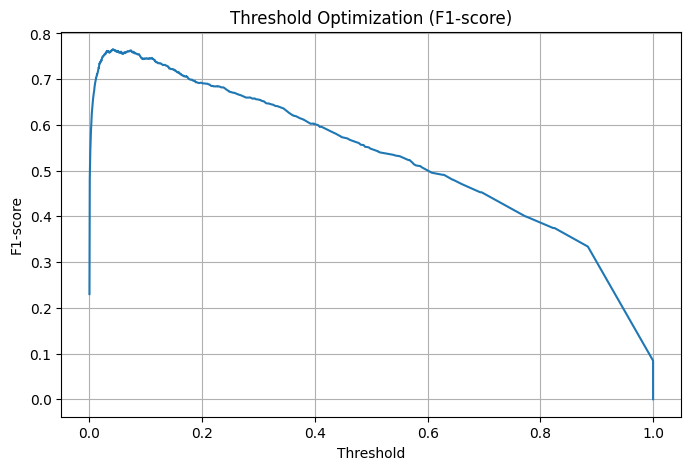

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(thresholds, f1_scores)
plt.xlabel("Threshold")
plt.ylabel("F1-score")
plt.title("Threshold Optimization (F1-score)")
plt.grid(True)
plt.show()


getting the best threshold

In [ ]:
final_threshold = best_f1_threshold

pred_classes_opt = (pred_probs > final_threshold).astype(int)

print("\nClassification Report with Optimized Threshold:")
print(classification_report(y_test, pred_classes_opt))

cm = confusion_matrix(y_test, pred_classes_opt)
print("Confusion Matrix:\n", cm)



Classification Report with Optimized Threshold:
              precision    recall  f1-score   support

           0       0.97      0.96      0.97      7317
           1       0.75      0.78      0.77      1066

    accuracy                           0.94      8383
   macro avg       0.86      0.87      0.87      8383
weighted avg       0.94      0.94      0.94      8383

Confusion Matrix:
 [[7043  274]
 [ 235  831]]


A lot better F1 score and recall for label 1 with the same accuracy Again!!

with the same weighted results

in our Case the higher recall is better


Let's see the ROC curve

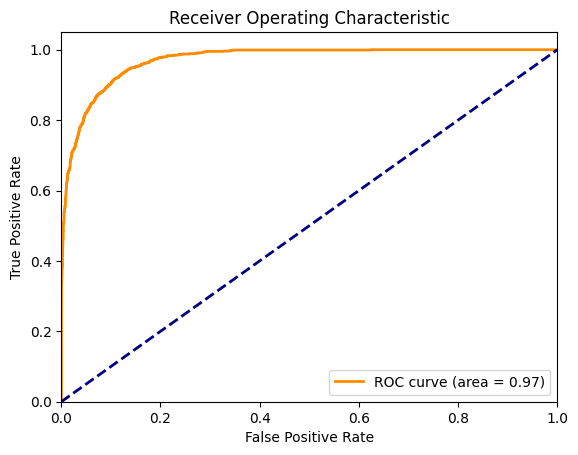

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()


stays the same

Let's see the confusion matrix

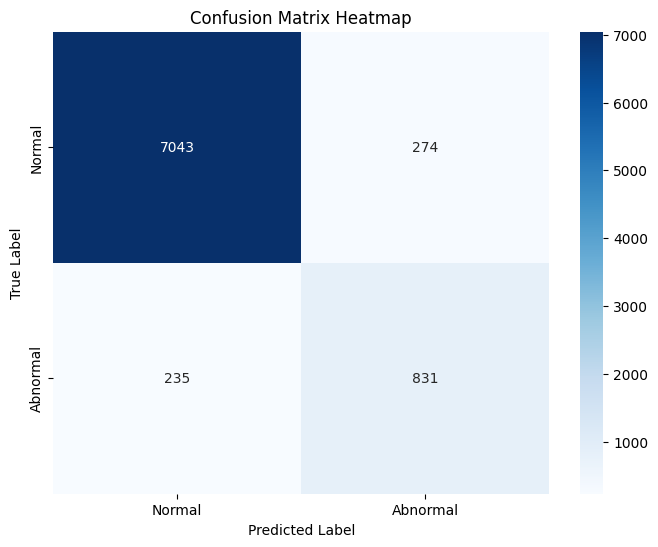

In [ ]:

cm = confusion_matrix(y_test, pred_classes_opt)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Abnormal'], yticklabels=['Normal', 'Abnormal'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap')
plt.show()

Detects More Abnormal and that's What we looking For

In [ ]:
model_resnet.save("/content/drive/MyDrive/breast_cancer_lu/resnet_model_breast_cancer_finetuned.h5")

## Balance the data

as the data is imbalanced so balancing it is a good solution for higher recall

we will balance the data by oversampling the (Minority Repetition) as it's the most memory effecient way for oversampling

Count the classes

In [ ]:
unique, counts = np.unique(y, return_counts=True)

print("Class Distribution:")
for u, c in zip(unique, counts):
    print(f"Label {u}: {c} samples")

label0_count = counts[unique.tolist().index(0)]
label1_count = counts[unique.tolist().index(1)]

Class Distribution:
Label 0: 48596 samples
Label 1: 7289 samples


Visualize class counts

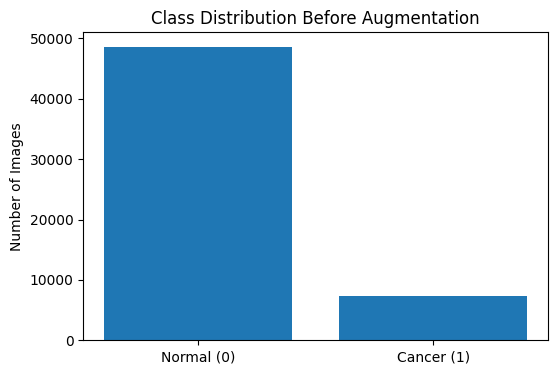

In [ ]:
plt.figure(figsize=(6,4))
plt.bar(['Normal (0)', 'Cancer (1)'], counts)
plt.title("Class Distribution Before Augmentation")
plt.ylabel("Number of Images")
plt.show()

We will oversample the train data only
as we don't want repitition in test or validation

In [ ]:
idx_label0 = np.where(y_train == 0)[0]  # majority
idx_label1 = np.where(y_train == 1)[0]  # minority

n_majority= len(idx_label0)
n_minority = len(idx_label1)

In [ ]:
repeat_factor = n_majority // n_minority + 1
idx_label1_oversample = np.tile(idx_label1, repeat_factor)[:n_majority]

# Combine with all majority indices
idx_balanced = np.concatenate([idx_label0, idx_label1_oversample])
np.random.shuffle(idx_balanced)

X_train_balanced = X_train[idx_balanced]
y_train_balanced = y_train[idx_balanced]

print("Balanced dataset shape:", X_train_balanced.shape)
print("Balanced label counts:", np.unique(y_train_balanced, return_counts=True))

Balanced dataset shape: (58224, 100, 100, 3)
Balanced label counts: (array([0, 1]), array([29112, 29112]))


sav the numpy data to save the RAM later

In [ ]:
np.save("/content/drive/MyDrive/breast_cancer_lu/X_train_balanced.npy", X_train_balanced)
np.save("/content/drive/MyDrive/breast_cancer_lu/y_train_balanced.npy", y_train_balanced)

In [ ]:
np.save("/content/drive/MyDrive/breast_cancer_lu/X_test.npy", X_test)
np.save("/content/drive/MyDrive/breast_cancer_lu/y_test.npy", y_test)
np.save("/content/drive/MyDrive/breast_cancer_lu/X_val.npy", X_val)
np.save("/content/drive/MyDrive/breast_cancer_lu/y_val.npy", y_val)

Load the Numpy data

In [ ]:
X_train_balanced = np.load("/content/drive/MyDrive/breast_cancer_lu/X_train_balanced.npy")
y_train_balanced = np.load("/content/drive/MyDrive/breast_cancer_lu/y_train_balanced.npy")

In [ ]:
X_test = np.load("/content/drive/MyDrive/breast_cancer_lu/X_test.npy")
y_test = np.load("/content/drive/MyDrive/breast_cancer_lu/y_test.npy")
X_val = np.load("/content/drive/MyDrive/breast_cancer_lu/X_val.npy")
y_val = np.load("/content/drive/MyDrive/breast_cancer_lu/y_val.npy")

train the finetuned resnet on the balanced data

In [ ]:
from tensorflow.keras.models import load_model
model_resnet = load_model("/content/drive/MyDrive/breast_cancer_lu/resnet_model_breast_cancer_finetuned.h5")

train the model

In [ ]:
model_resnet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='AUC')]
)


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import tensorflow as tf # Ensure tensorflow is imported

tf.config.run_functions_eagerly(True) # Explicitly enable eager execution

early_stop = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
checkpoint = ModelCheckpoint("finetuned_balanced_resnet.h5", save_best_only=True)

history_ft = model_resnet.fit(
    X_train_balanced, y_train_balanced,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop, checkpoint]
)

/usr/local/lib/python3.12/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


Epoch 1/10
1820/1820 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - AUC: 0.9699 - accuracy: 0.9051 - loss: 0.2215

1820/1820 ━━━━━━━━━━━━━━━━━━━━ 348s 190ms/step - AUC: 0.9699 - accuracy: 0.9051 - loss: 0.2215 - val_AUC: 0.9578 - val_accuracy: 0.9277 - val_loss: 0.2110
Epoch 2/10
1820/1820 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - AUC: 0.9721 - accuracy: 0.9094 - loss: 0.2104

1820/1820 ━━━━━━━━━━━━━━━━━━━━ 339s 186ms/step - AUC: 0.9721 - accuracy: 0.9094 - loss: 0.2104 - val_AUC: 0.9635 - val_accuracy: 0.9343 - val_loss: 0.1852
Epoch 3/10
1820/1820 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - AUC: 0.9741 - accuracy: 0.9153 - loss: 0.2029

1820/1820 ━━━━━━━━━━━━━━━━━━━━ 336s 185ms/step - AUC: 0.9741 - accuracy: 0.9153 - loss: 0.2029 - val_AUC: 0.9676 - val_accuracy: 0.9366 - val_loss: 0.1694
Epoch 4/10
1820/1820 ━━━━━━━━━━━━━━━━━━━━ 352s 193ms/step - AUC: 0.9755 - accuracy: 0.9176 - loss: 0.1973 - val_AUC: 0.9683 - val_accuracy: 0.9361 - val_loss: 0.1718
Epoch 5/10
1820/1820 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - AUC: 0.9770 - accuracy: 0.9210 - loss: 0.1903

1820/1820 ━━━━━━━━━━━━━━━━━━━━ 335s 184ms/step - AUC: 0.9770 - accuracy: 0.9210 - loss: 0.1903 - val_AUC: 0.9687 - val_accuracy: 0.9396 - val_loss: 0.1622
Epoch 6/10
1820/1820 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - AUC: 0.9780 - accuracy: 0.9208 - loss: 0.1867

1820/1820 ━━━━━━━━━━━━━━━━━━━━ 329s 181ms/step - AUC: 0.9780 - accuracy: 0.9208 - loss: 0.1867 - val_AUC: 0.9727 - val_accuracy: 0.9414 - val_loss: 0.1469
Epoch 7/10
1820/1820 ━━━━━━━━━━━━━━━━━━━━ 397s 189ms/step - AUC: 0.9786 - accuracy: 0.9235 - loss: 0.1841 - val_AUC: 0.9666 - val_accuracy: 0.9395 - val_loss: 0.1704
Epoch 8/10
1820/1820 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - AUC: 0.9797 - accuracy: 0.9247 - loss: 0.1810

1820/1820 ━━━━━━━━━━━━━━━━━━━━ 339s 186ms/step - AUC: 0.9797 - accuracy: 0.9247 - loss: 0.1810 - val_AUC: 0.9718 - val_accuracy: 0.9447 - val_loss: 0.1456
Epoch 9/10
1820/1820 ━━━━━━━━━━━━━━━━━━━━ 339s 186ms/step - AUC: 0.9806 - accuracy: 0.9283 - loss: 0.1745 - val_AUC: 0.9664 - val_accuracy: 0.9406 - val_loss: 0.1644
Epoch 10/10
1820/1820 ━━━━━━━━━━━━━━━━━━━━ 350s 192ms/step - AUC: 0.9798 - accuracy: 0.9255 - loss: 0.1775 - val_AUC: 0.9507 - val_accuracy: 0.9337 - val_loss: 0.2151


In [ ]:
model_resnet.save("/content/drive/MyDrive/breast_cancer_lu/finetuned_balanced_resnet.h5")

Calculate the best threshold for the F1 score

In [ ]:
pred_probs = model_resnet.predict(X_test).flatten()
fpr, tpr, thresholds = roc_curve(y_test, pred_probs)
f1_scores = []
for th in thresholds:
    preds = (pred_probs > th).astype(int)
    f1_scores.append(f1_score(y_test, preds))

best_f1_threshold = thresholds[np.argmax(f1_scores)]

print("Best Threshold (F1-score):", best_f1_threshold)


262/262 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step
Best Threshold (F1-score): 0.20042022


plot of thresholds

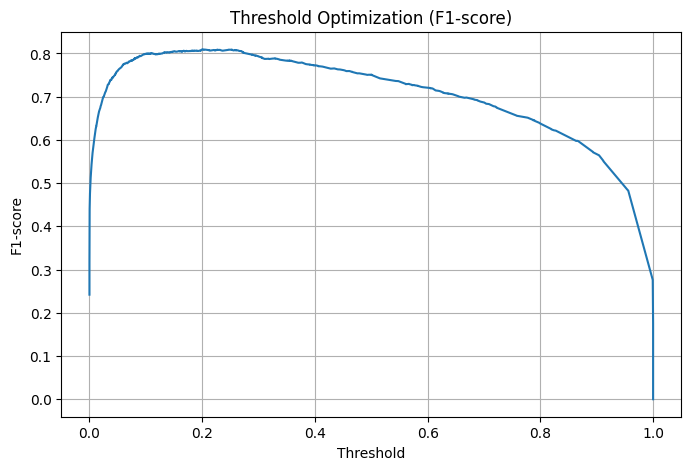

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(thresholds, f1_scores)
plt.xlabel("Threshold")
plt.ylabel("F1-score")
plt.title("Threshold Optimization (F1-score)")
plt.grid(True)
plt.show()


evaluation with the best threshold

In [ ]:
final_threshold = best_f1_threshold

pred_classes_opt = (pred_probs > final_threshold).astype(int)

print("\nClassification Report with Optimized Threshold:")
print(classification_report(y_test, pred_classes_opt))

cm = confusion_matrix(y_test, pred_classes_opt)
print("Confusion Matrix:\n", cm)



Classification Report with Optimized Threshold:
              precision    recall  f1-score   support

           0       0.97      0.98      0.97      7272
           1       0.84      0.78      0.81      1111

    accuracy                           0.95      8383
   macro avg       0.90      0.88      0.89      8383
weighted avg       0.95      0.95      0.95      8383

Confusion Matrix:
 [[7106  166]
 [ 242  869]]


Precision, F1-score All increase for label 1 and weighted and also accuracy became 95%


Let's see the ROC curve

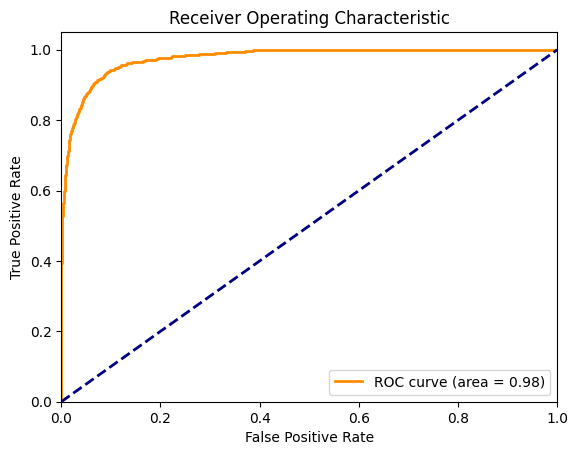

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()


increased to 0.98

Let's see the confusion matrix

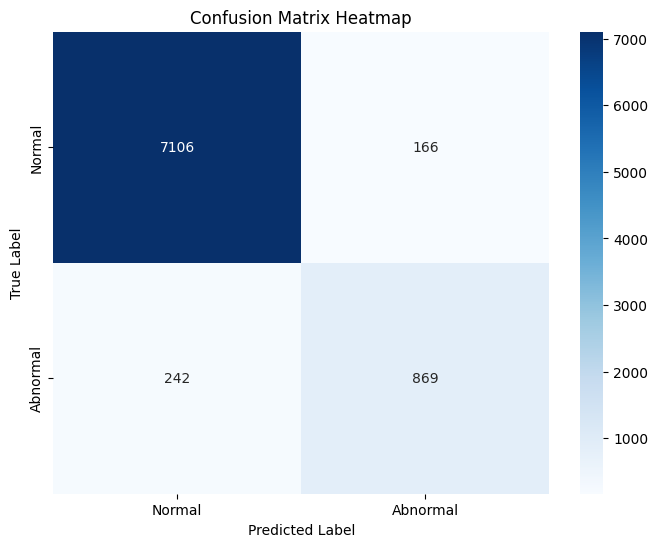

In [ ]:

cm = confusion_matrix(y_test, pred_classes_opt)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Abnormal'], yticklabels=['Normal', 'Abnormal'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap')
plt.show()

TN incresed
FP decreased